In [ ]:
# Final Benchmark and Risk-Adjusted Performance

This notebook provides the final benchmark comparison for the portfolio strategies.

It adds:

- BIL as a practical cash proxy for excess-return calculations
- Passive SPY buy-and-hold as an external benchmark
- Final Sharpe and Sortino ratios relative to BIL
- Final VaR, CVaR, volatility, drawdown, and CAGR comparison
- Presentation-ready benchmark figures

The purpose is to distinguish absolute return performance from risk-adjusted portfolio efficiency.

In [3]:
import os
import requests
import pandas as pd
import numpy as np
from pathlib import Path
from dotenv import load_dotenv


# ==========================================
# 1. Paths and API key
# ==========================================

data_dir = Path("../data")
output_dir = Path("../outputs")

data_dir.mkdir(exist_ok=True)
output_dir.mkdir(exist_ok=True)

load_dotenv("../.env", override=True)

API_KEY = os.getenv("TIINGO_API_KEY")

if API_KEY is None:
    raise ValueError(
        "TIINGO_API_KEY not found. "
        "Create a .env file in the project root."
    )


# ==========================================
# 2. Download BIL as cash proxy
# ==========================================

url = "https://api.tiingo.com/tiingo/daily/BIL/prices"

params = {
    "startDate": "2010-01-01",
    "endDate": "2025-12-31"
}

headers = {
    "Content-Type": "application/json",
    "Authorization": f"Token {API_KEY}"
}

response = requests.get(
    url,
    params=params,
    headers=headers,
    timeout=(15, 120)
)

if response.status_code != 200:
    raise RuntimeError(
        f"BIL download failed: "
        f"HTTP {response.status_code}\n"
        f"{response.text[:500]}"
    )

bil = pd.DataFrame(
    response.json()
)

if bil.empty:
    raise ValueError(
        "No BIL data returned."
    )

bil["date"] = (
    pd.to_datetime(
        bil["date"]
    )
    .dt.tz_localize(None)
)

bil = (
    bil.set_index("date")
    .sort_index()
)

bil.to_csv(
    data_dir / "BIL_daily.csv"
)

bil_returns = (
    bil["adjClose"]
    .pct_change()
    .dropna()
)

print(
    "BIL cash proxy:",
    bil.index.min().date(),
    "→",
    bil.index.max().date(),
    "| rows:",
    len(bil)
)


# ==========================================
# 3. Load OOS strategy backtests
# ==========================================

strategies = [
    "EqualWeight",
    "GMV",
    "MaxSharpe",
    "RiskParity"
]

backtests = {}

for strategy in strategies:

    backtests[strategy] = pd.read_csv(
        output_dir
        / f"{strategy}_oos_backtest.csv",
        index_col=0,
        parse_dates=True
    )

oos_start = (
    backtests["EqualWeight"]
    .index.min()
)

oos_end = (
    backtests["EqualWeight"]
    .index.max()
)

print(
    "\nOOS period:",
    oos_start.date(),
    "→",
    oos_end.date()
)


# ==========================================
# 4. Construct passive SPY benchmark
# ==========================================

prices = pd.read_csv(
    data_dir / "adjusted_close.csv",
    index_col=0,
    parse_dates=True
)

asset_returns = (
    prices
    .pct_change()
    .dropna()
)

spy_returns = (
    asset_returns["SPY"]
    .loc[oos_start:oos_end]
)

spy_backtest = pd.DataFrame(
    index=spy_returns.index
)

spy_backtest["Return"] = (
    spy_returns
)

spy_backtest["Wealth"] = (
    1 + spy_returns
).cumprod()

spy_backtest["Turnover"] = 0.0

spy_backtest.to_csv(
    output_dir
    / "SPY_buyhold_oos_backtest.csv"
)


# ==========================================
# 5. Cash-proxy-adjusted performance metrics
# ==========================================

def final_metrics(
    backtest,
    cash_returns
):

    portfolio_returns = (
        backtest["Return"]
        .dropna()
    )

    aligned = pd.concat(
        [
            portfolio_returns.rename(
                "Portfolio"
            ),
            cash_returns.rename(
                "Cash"
            )
        ],
        axis=1,
        join="inner"
    ).dropna()

    portfolio_r = (
        aligned["Portfolio"]
    )

    cash_r = (
        aligned["Cash"]
    )

    excess_returns = (
        portfolio_r
        - cash_r
    )

    wealth = (
        1 + portfolio_r
    ).cumprod()

    years = (
        wealth.index[-1]
        - wealth.index[0]
    ).days / 365.25

    cagr = (
        wealth.iloc[-1]
    ) ** (1 / years) - 1

    annual_volatility = (
        portfolio_r.std()
        * np.sqrt(252)
    )

    # Sharpe ratio based on daily excess returns
    sharpe = (
        excess_returns.mean()
        / excess_returns.std()
        * np.sqrt(252)
    )

    # Sortino ratio using downside deviation
    # of excess returns relative to zero
    downside_excess = np.minimum(
        excess_returns,
        0
    )

    downside_deviation = (
        np.sqrt(
            np.mean(
                downside_excess ** 2
            )
        )
        * np.sqrt(252)
    )

    sortino = (
        excess_returns.mean()
        * 252
        / downside_deviation
    )

    drawdown = (
        wealth
        / wealth.cummax()
        - 1
    )

    max_drawdown = (
        drawdown.min()
    )

    # Historical 95% VaR and CVaR
    q05 = (
        portfolio_r
        .quantile(0.05)
    )

    var_95 = -q05

    cvar_95 = -portfolio_r[
        portfolio_r <= q05
    ].mean()

    return pd.Series(
        {
            "CAGR":
                cagr,

            "Annualized_Volatility":
                annual_volatility,

            "Sharpe_vs_BIL":
                sharpe,

            "Sortino_vs_BIL":
                sortino,

            "Maximum_Drawdown":
                max_drawdown,

            "Daily_VaR_95":
                var_95,

            "Daily_CVaR_95":
                cvar_95
        }
    )


# ==========================================
# 6. Final strategy comparison
# ==========================================

final_results = {}

for strategy in strategies:

    final_results[strategy] = (
        final_metrics(
            backtests[strategy],
            bil_returns
        )
    )

final_results["SPY_BuyHold"] = (
    final_metrics(
        spy_backtest,
        bil_returns
    )
)

final_table = pd.DataFrame(
    final_results
).T

print(
    "\n=== Final Out-of-Sample Comparison ==="
)

display(
    final_table.round(4)
)

final_table.to_csv(
    output_dir
    / "final_strategy_comparison.csv"
)


# ==========================================
# 7. Wealth comparison including SPY
# ==========================================

wealth_comparison = pd.DataFrame(
    {
        strategy:
            backtests[strategy]["Wealth"]

        for strategy
        in strategies
    }
)

wealth_comparison[
    "SPY_BuyHold"
] = (
    spy_backtest["Wealth"]
)

wealth_comparison.to_csv(
    output_dir
    / "final_wealth_comparison.csv"
)


# ==========================================
# 8. Validation
# ==========================================

print(
    "\nMissing values in final table:",
    final_table.isna().sum().sum()
)

print(
    "Strategies compared:",
    len(final_table)
)

print(
    "\nFinal comparison files saved."
)

BIL cash proxy: 2010-01-04 → 2025-12-31 | rows: 4024

OOS period: 2011-01-04 → 2025-12-31

=== Final Out-of-Sample Comparison ===


,CAGR,Annualized_Volatility,Sharpe_vs_BIL,Sortino_vs_BIL,Maximum_Drawdown,Daily_VaR_95,Daily_CVaR_95
EqualWeight,0.0915,0.1323,0.6289,0.8775,-0.2719,0.0123,0.0195
GMV,0.0840,0.0889,0.8047,1.1386,-0.2578,0.0088,0.0128
MaxSharpe,0.0921,0.1306,0.6401,0.8959,-0.2910,0.0127,0.0201
RiskParity,0.0901,0.1210,0.6652,0.9308,-0.2657,0.0113,0.0180
SPY_BuyHold,0.1389,0.1717,0.7677,1.0773,-0.3370,0.0164,0.0262



Missing values in final table: 0
Strategies compared: 5

Final comparison files saved.


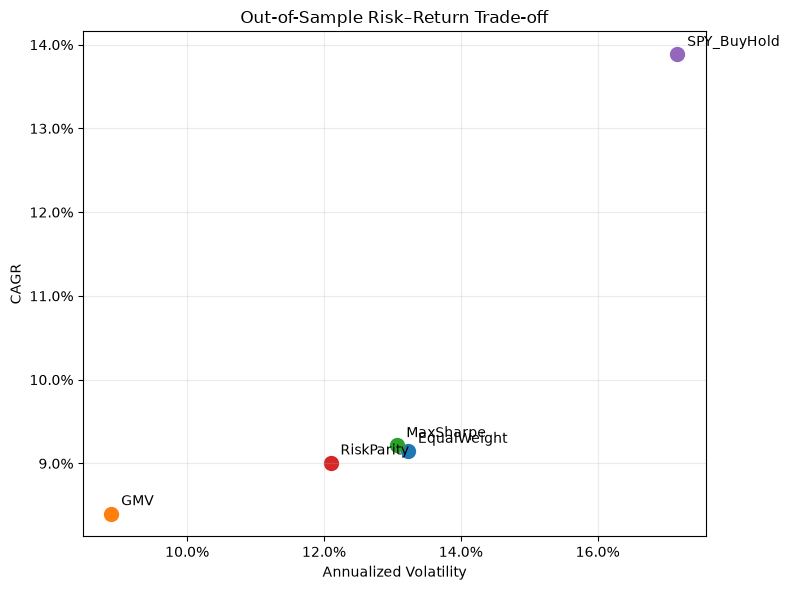

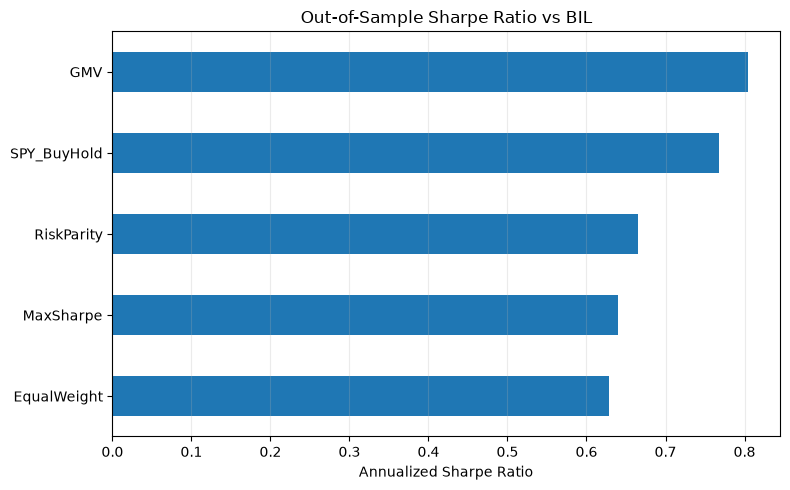

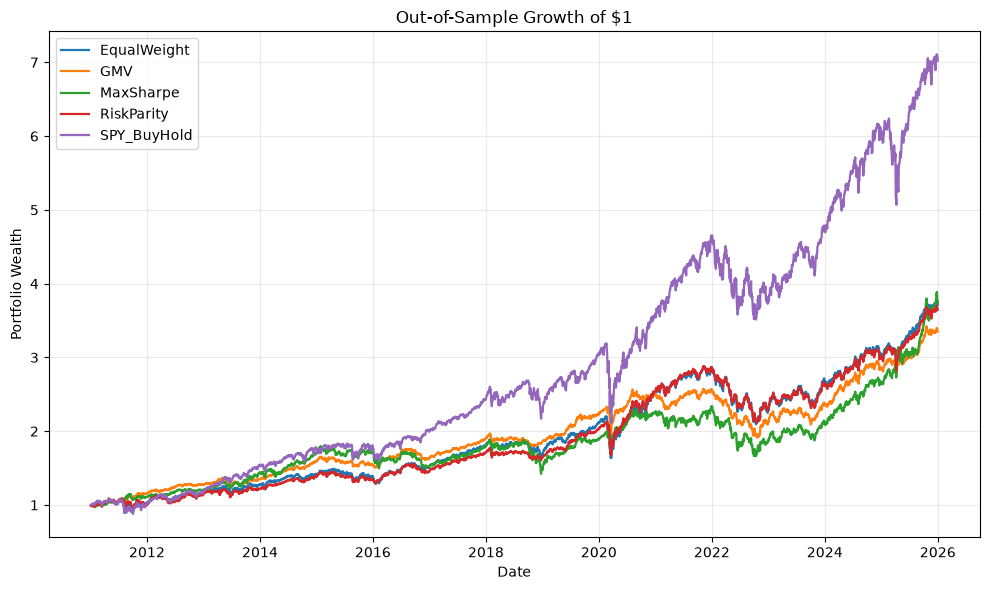

Final presentation figures saved.


In [4]:
import matplotlib.pyplot as plt

# ==========================================
# Final Figure 1:
# Risk-return including SPY
# ==========================================

fig, ax = plt.subplots(figsize=(8, 6))

for strategy in final_table.index:

    x = final_table.loc[
        strategy,
        "Annualized_Volatility"
    ]

    y = final_table.loc[
        strategy,
        "CAGR"
    ]

    ax.scatter(
        x,
        y,
        s=100
    )

    ax.annotate(
        strategy,
        (x, y),
        xytext=(7, 6),
        textcoords="offset points"
    )

ax.set_title(
    "Out-of-Sample Risk–Return Trade-off"
)

ax.set_xlabel(
    "Annualized Volatility"
)

ax.set_ylabel(
    "CAGR"
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"{x:.1%}"
    )
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda y, _: f"{y:.1%}"
    )
)

ax.grid(alpha=0.25)

fig.tight_layout()

fig.savefig(
    output_dir / "06_final_risk_return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# Final Figure 2:
# Sharpe ratio comparison
# ==========================================

sharpe = (
    final_table["Sharpe_vs_BIL"]
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 5))

sharpe.plot(
    kind="barh",
    ax=ax
)

ax.set_title(
    "Out-of-Sample Sharpe Ratio vs BIL"
)

ax.set_xlabel(
    "Annualized Sharpe Ratio"
)

ax.set_ylabel(
    ""
)

ax.grid(
    axis="x",
    alpha=0.25
)

fig.tight_layout()

fig.savefig(
    output_dir / "07_final_sharpe.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# Final Figure 3:
# Wealth comparison including SPY
# ==========================================

fig, ax = plt.subplots(figsize=(10, 6))

for strategy in wealth_comparison.columns:

    ax.plot(
        wealth_comparison.index,
        wealth_comparison[strategy],
        label=strategy,
        linewidth=1.6
    )

ax.set_title(
    "Out-of-Sample Growth of $1"
)

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Portfolio Wealth"
)

ax.legend()

ax.grid(alpha=0.25)

fig.tight_layout()

fig.savefig(
    output_dir / "08_final_wealth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final presentation figures saved.")